### [주제 : 사과 & 바나나 분류 - (3) 학습 및 평가]
- **[1] 학습 종류와 학습 방법/모델**
- **[2] 평가**

- **학습 종류와 학습 방법/모델**
    * 학습 종류 : 지도 학습 - 분류
    * 학습 방법/모델 : 분류 모델들 중 선택

- **학습/모델 평가**
    * 학습에 사용되지 않은 데이터로 평가 = 테스트 데이터셋

In [1]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

#### [1] 데이터

In [2]:
# => 이미지 관련
DATA_FILE = './fruit_data.csv'

df = pd.read_csv(DATA_FILE)

df.info()
display(df.head(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Columns: 10001 entries, pixel0 to label
dtypes: int64(10000), object(1)
memory usage: 33.4+ MB


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel9991,pixel9992,pixel9993,pixel9994,pixel9995,pixel9996,pixel9997,pixel9998,pixel9999,label
0,112,113,114,116,116,118,123,129,129,131,...,83,69,61,53,48,43,41,38,36,apple
1,102,102,103,104,104,104,104,104,103,103,...,61,62,60,62,69,67,62,69,76,apple
2,48,49,51,53,54,54,55,55,55,56,...,23,24,37,49,64,85,105,112,119,apple


#### [2] 데이터와 타겟/라벨 분리

In [3]:
# => 학습 데이터와 정답지 타겟 분리
# X(픽셀데이터) / y(라벨) 분리
x = df.iloc[:,:-1].values # ndarray
y = df['label'].values    # ndarray

# => 숫자 학습 데이터는 학습 안정화를 위해서 정규화 0~1
# 3) 데이터 정규화
x = x / 255.0

print(f'정규화 후 : \n{x[:3, :]}')

정규화 후 : 
[[0.43921569 0.44313725 0.44705882 ... 0.16078431 0.14901961 0.14117647]
 [0.4        0.4        0.40392157 ... 0.24313725 0.27058824 0.29803922]
 [0.18823529 0.19215686 0.2        ... 0.41176471 0.43921569 0.46666667]]


#### [3] 학습용 / 테스트용 데이터셋 분리
* 학습용 데이터셋 => 일부를 테스트 데이터셋 사용
* 함수 : train_test_split()
    - 전체 학습용 데이터셋에 몇 %로 할지 설정 [default] 학습용 : 테스트용 = 75% : 25%
    - 데이터를 섞어 주는 작업
    - 불균형 데이터 셋에 대한 설정

In [4]:
# 4) 학습용 / 테스트용 데이터 분리 (80% : 20%)
# => 데이터 : 2D
# => 라벨 : 1D
# => 제현성 : random_state= 숫저 데이터셋을 섞지만, 매번 동일하게
# => 균현 : 데이터셋의 균형 맞추기, 분ㄴ류일때만 필요
X_train, X_test, y_train, y_test = train_test_split( x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print(f'train : {X_train.shape}, test : {X_test.shape}')

train : (350, 10000), test : (88, 10000)


#### [4] 모델 생성 및 학습

In [5]:
# => 모델 생성 및 학습
kModel   = KNeighborsClassifier()
svcModel = SVC(kernel='linear')

kModel.fit(X_train, y_train)
svcModel.fit(X_train, y_train)

SVC(kernel='linear')

#### [5] 평가
- 학습용 데이터 => 점수
- 테스트용 데이터 => 점수
- 메서드 : score(2D데이터, 1D정답)

In [6]:
# 학습용 데이터셋 점수
knn_train_score = kModel.score(X_train, y_train)
svc_train_score = svcModel.score(X_train, y_train)

# 테스터용 데이터셋 점수
knn_test_score = kModel.score(X_test, y_test)
svc_test_score = svcModel.score(X_test, y_test)

print(f" KNN : [TRAIN] {knn_train_score}점 [TEST] {knn_test_score}점")
print(f" SVC : [TRAIN] {svc_train_score}점 [TEST] {svc_test_score}점")

c:\Users\Win11Pro\anaconda3\envs\CV_ENV\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


 KNN : [TRAIN] 0.8742857142857143점 [TEST] 0.8522727272727273점
 SVC : [TRAIN] 1.0점 [TEST] 0.7954545454545454점


#### [6] 예측 : predict(2D 데이터)

In [7]:
# 테스트 데이터 1개 선택 : 1D => 2D
data = X_test[0].reshape(1,-1)
pre_y = kModel.predict(data)
print(f"{pre_y[0]}, {y_test[0]}")

banana, banana


In [8]:
# 새롭게 수집된 데이터 활용한 예측
# => 학습 시 사용한 데이터셋 형태로 변환
#   -> 사이즈 100x100
#   -> 그레이 스케일
#   -> 픽셀값 0 ~ 255 => 0 ~ 1 정규화

# 함수기능 : 학습용 데이터 변환 처리
# 매개변수 : 파일 경로 + 파일명
def convert_data(filepath):
    import cv2
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    # 비율유지 50% 줄이기
    res = cv2.resize(img, (0,0), fx=0.5, fy=0.5)
    # 절대크기 줄이기
    res = cv2.resize(res, (100,100))

    # 정규화
    res = res/255.0
    return res

예측: ['banana' 'banana' 'apple' 'apple'], 정답: ['apple05.jpg', 'banana.jpg', 'pear2.jpg', 'pear3.jpg']


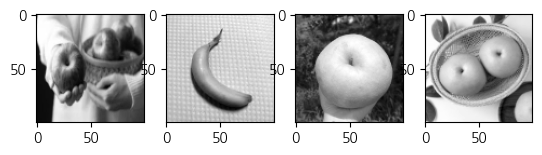

In [9]:
files = ['./apple05.jpg', './banana.jpg', './pear2.jpg', './pear3.jpg']
new_data = [ convert_data(filepath).flatten() for filepath in files]
new_label = [file.split('/')[-1] for file in files]

# new_data = [ convert_data(filepath).reshape(1,-1) for filepath in files]
# new_data = np.vstack(new_data)

# 예측
pre_y = svcModel.predict(new_data)
print(f"예측: {pre_y}, 정답: {new_label}")

_, axes = plt.subplots(1,4)
for i, ax in enumerate(axes):
    ax.imshow(new_data[i].reshape(100, 100), cmap='gray')
plt.show()